In [2]:
from google.colab import drive, files
import os, zipfile, torch, torch.nn as nn, torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

# Подключаем Drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/plant_project', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Drive подключён! Используем: {device}")

Mounted at /content/drive
Drive подключён! Используем: cpu


In [3]:
# Загружаем kaggle.json
files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Скачиваем и распаковываем
if not os.path.exists('data/train'):
    !kaggle competitions download -c plant-seedlings-classification
    with zipfile.ZipFile('plant-seedlings-classification.zip', 'r') as zip_ref:
        zip_ref.extractall('data')
    print("Датасет готов!")
else:
    print("Датасет уже есть!")

Saving kaggle.json to kaggle.json
100% 1.69G/1.69G [00:13<00:00, 131MB/s]

Датасет готов!


In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder('data/train', transform=train_transforms)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Классов: {len(full_dataset.classes)}")
print(f"Обучение: {train_size} фото | Валидация: {val_size} фото")


Классов: 12
Обучение: 3800 фото | Валидация: 950 фото


In [5]:
model_path = '/content/drive/MyDrive/plant_project/plant_model.pth'

model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 12)

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    already_trained = True
    print("Модель загружена с Drive — обучение не нужно!")
else:
    already_trained = False
    print("Модель будет обучена с нуля")

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 118MB/s] 


Модель загружена с Drive — обучение не нужно!


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

if not already_trained:
    for epoch in range(10):
        model.train()
        train_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_acc = 100. * val_correct / val_total
        scheduler.step(val_loss)
        print(f"Эпоха {epoch+1}/10 | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%")

    torch.save(model.state_dict(), model_path)
    print("\nМодель сохранена на Drive!")
else:
    print("Пропускаем обучение!")

Пропускаем обучение!


                           precision    recall  f1-score   support

              Black-grass       0.87      0.95      0.91        64
                 Charlock       0.99      1.00      0.99        71
                 Cleavers       1.00      1.00      1.00        59
         Common Chickweed       1.00      0.96      0.98       134
             Common wheat       1.00      0.86      0.93        43
                  Fat Hen       1.00      0.99      0.99        83
         Loose Silky-bent       0.98      0.93      0.95       123
                    Maize       0.95      1.00      0.97        35
        Scentless Mayweed       0.96      1.00      0.98       114
          Shepherds Purse       0.96      0.98      0.97        48
Small-flowered Cranesbill       0.95      1.00      0.97        97
               Sugar beet       1.00      0.99      0.99        79

                 accuracy                           0.97       950
                macro avg       0.97      0.97      0.97    

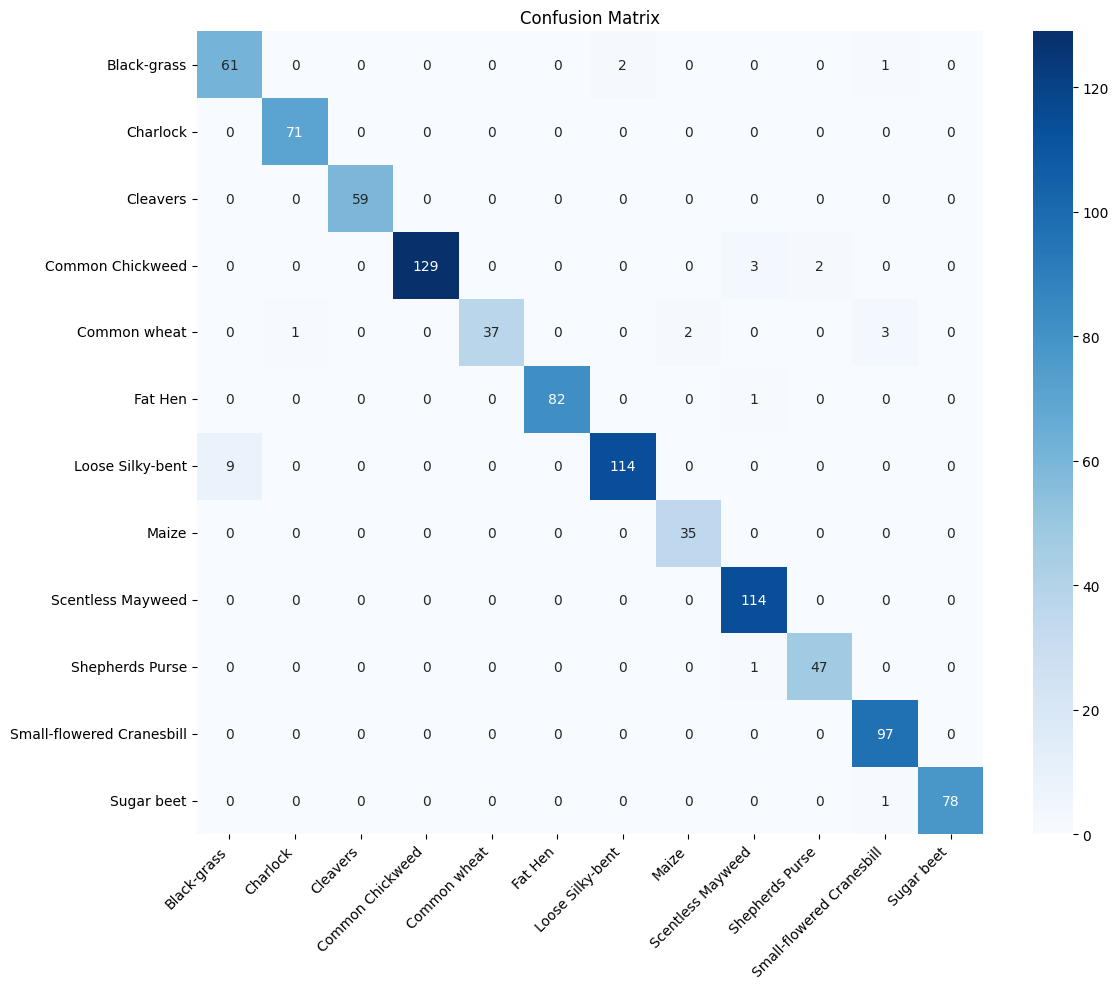

Сохранено на Drive!


In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

classes = full_dataset.classes

# Per-class accuracy
print(classification_report(all_labels, all_preds, target_names=classes))

# Confusion matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xticks(rotation=45, ha='right')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/plant_project/results/confusion_matrix.png')
plt.show()
print("Сохранено на Drive!")

Матрица ошибок построена на валидационной выборке (~950 изображений). Большинство классов модель определяет безошибочно — например, Charlock (71/71), Cleavers (59/59), Maize (35/35) и Scentless Mayweed (114/114) классифицированы с точностью 100%. Наибольшая путаница возникла между классами Loose Silky-bent и Black-grass: 9 изображений Loose Silky-bent были ошибочно отнесены к Black-grass. В остальных классах количество ошибок не превышает 3, что говорит о высокой точности модели в целом.

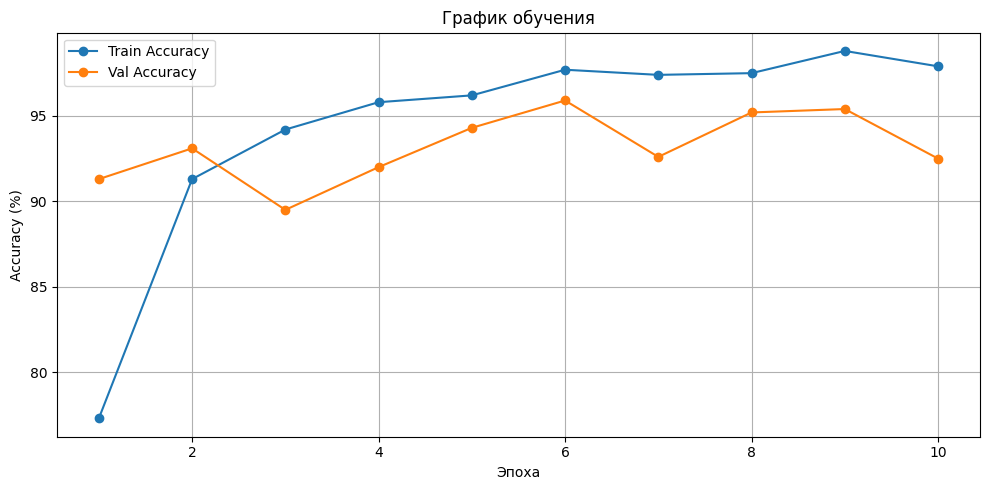

Сохранено!


In [8]:
epochs = list(range(1, 11))
train_accs = [77.3, 91.3, 94.2, 95.8, 96.2, 97.7, 97.4, 97.5, 98.8, 97.9]
val_accs = [91.3, 93.1, 89.5, 92.0, 94.3, 95.9, 92.6, 95.2, 95.4, 92.5]

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accs, label='Train Accuracy', marker='o')
plt.plot(epochs, val_accs, label='Val Accuracy', marker='o')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.title('График обучения')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/plant_project/results/training_plot.png')
plt.show()
print("Сохранено!")


График отражает динамику точности модели на протяжении 10 эпох обучения. В первой эпохе Train Accuracy составила 77.3%, однако уже к третьей эпохе достигла 94.2%, а к девятой — 98.8%. Val Accuracy с первой эпохи держалась на высоком уровне (91.3%) и достигла максимума в 95.9% на шестой эпохе. Небольшие колебания валидационной точности объясняются случайным разбиением данных. Разрыв между Train и Val Accuracy не превышает 6%, что свидетельствует об отсутствии переобучения — модель уверенно обобщает на новых, ранее не виденных изображениях.
